In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans #partitions an unlabeled dataset into distinct groups (clusters) based on feature similarity
from sklearn.preprocessing import StandardScaler

#Use the make_blobs tool in Python to build fake datasets.
#It creates groups of data points shaped like round clouds.
#These clouds have a Gaussian distribution (data forms a bell curve around the center)

In [19]:
X, y_true = make_blobs(n_samples=500, centers=3, n_features=2,cluster_std=0.60,random_state=42)

In [20]:
df = pd.DataFrame(X,columns=["Feature_1","Feature_2"])

In [21]:
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [22]:
scaler = StandardScaler()
X_scaler = scaler.fit_transform(df)

In [23]:
inertia = []
K_range = range(1,11)

In [24]:
for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaler)
    inertia.append(kmeans.inertia_)

In [25]:
inertia

[1000.0,
 297.8954141051723,
 11.575484723104982,
 9.752067977356841,
 8.257175272446284,
 6.9175773204168,
 6.334755391595291,
 5.70417717790143,
 5.0602341335320755,
 4.762361898130395]

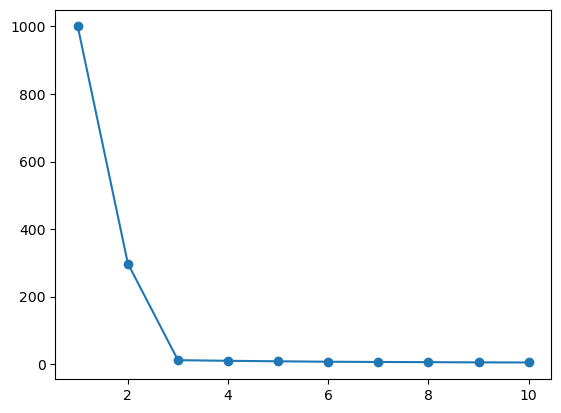

In [26]:
plt.plot(K_range,inertia,marker = "o")

In [27]:
kmeans_final = KMeans(n_clusters=3,random_state=42)

In [29]:
cluster_labels = kmeans_final.fit_predict(X_scaler)

In [31]:
df["cluster"] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

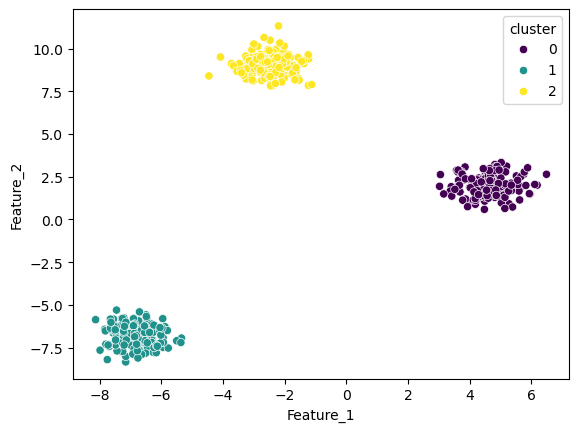

In [33]:
sns.scatterplot(x=df["Feature_1"],y=df["Feature_2"],hue=df["cluster"],palette="viridis")